In [1]:
!pip install deepface

In [2]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from deepface import DeepFace
from scipy.stats import t
import zipfile
import json

In [3]:
def load_bupt_subset(zip_path="bupt_6000_pairs.zip"):
    """Load the pre-prepared BUPT subset with 6000 pairs"""

    print("Extracting BUPT subset...")

    # Extract the subset
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("bupt_subset")

    # Load metadata
    with open("bupt_subset/pairs_metadata.json", 'r') as f:
        metadata = json.load(f)

    print(f"Loaded dataset with {metadata['total_pairs']} pairs")
    print(f"  - Genuine pairs: {metadata['genuine_pairs']}")
    print(f"  - Impostor pairs: {metadata['impostor_pairs']}")

    # Get pairs and labels
    pairs = []
    labels = []

    for pair_info in metadata['pairs']:
        img1_path = os.path.join("bupt_subset", pair_info['img1'])
        img2_path = os.path.join("bupt_subset", pair_info['img2'])
        pairs.append((img1_path, img2_path))
        labels.append(pair_info['label'])

    return pairs, np.array(labels)

In [4]:
def evaluate(distances, labels):
    labels = np.array(labels)
    distances = np.array(distances)
    thresholds = np.linspace(distances.min(), distances.max(), 1000)

    best_acc, best_thresh = 0, 0
    far_list, frr_list = [], []

    for thresh in thresholds:
        preds = distances < thresh
        acc = accuracy_score(labels, preds)
        far = np.mean((preds == 1) & (labels == 0))
        frr = np.mean((preds == 0) & (labels == 1))

        far_list.append(far)
        frr_list.append(frr)

        if acc > best_acc:
            best_acc, best_thresh = acc, thresh

    eer_idx = np.argmin(np.abs(np.array(far_list) - np.array(frr_list)))
    eer = (far_list[eer_idx] + frr_list[eer_idx]) / 2
    auc = roc_auc_score(labels, -distances)
    preds_at_best_thresh = distances < best_thresh

    return {
        "best_thresh": best_thresh,
        "best_acc": best_acc,
        "eer_far": far_list[eer_idx],
        "eer_frr": frr_list[eer_idx],
        "eer": eer,
        "auc": auc,
        "y_pred_at_best_thresh": preds_at_best_thresh
    }

In [5]:
def find_optimal_threshold(distances, labels):
    labels = np.array(labels)
    distances = np.array(distances)
    thresholds = np.linspace(distances.min(), distances.max(), 1000)
    best_acc = 0
    best_thresh = 0
    for t in thresholds:
        preds = distances < t
        acc = accuracy_score(labels, preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh = t
    return best_thresh

In [6]:
# Main evaluation parameters
models = ["Facenet", "ArcFace", "Facenet512"]
detector_backend = "retinaface"
distance_metric = "cosine"
align = True
n_splits = 10

In [7]:
# Load the pre-prepared dataset
print("Loading BUPT subset...")
pairs, labels = load_bupt_subset("/content/bupt_6000_pairs.zip")
instances = len(labels)

print(f"\nDataset loaded:")
print(f"Total pairs: {instances}")
print(f"Genuine: {sum(labels)} ({100*sum(labels)/len(labels):.1f}%)")
print(f"Impostor: {len(labels) - sum(labels)} ({100*(len(labels)-sum(labels))/len(labels):.1f}%)")

Loading BUPT subset...
Extracting BUPT subset...
Loaded dataset with 6000 pairs
  - Genuine pairs: 3000
  - Impostor pairs: 3000

Dataset loaded:
Total pairs: 6000
Genuine: 3000 (50.0%)
Impostor: 3000 (50.0%)


In [8]:
# Initialize results storage
all_cv_results = {model_name: {'accuracies': [], 'eers': [], 'aucs': [], 'distances': [], 'fold_labels': []}
                  for model_name in models}
y_trues_all_folds = []
y_preds_all_folds = {model_name: [] for model_name in models}

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [9]:
print(f"\nStarting {n_splits}-fold cross-validation on BUPT-CBFace...")
print("=" * 60)

for fold_num, (train_index, test_index) in enumerate(skf.split(np.arange(instances), labels)):
    print(f"\nFold {fold_num + 1}/{n_splits}")
    print("-" * 40)

    fold_labels = labels[test_index]
    y_trues_all_folds.extend(fold_labels)

    for model_name in models:
        distances = []

        for i in tqdm(range(len(test_index)), desc=f"{model_name}"):
            img1 = pairs[test_index[i]][0]
            img2 = pairs[test_index[i]][1]

            result = DeepFace.verify(
                img1, img2,
                model_name=model_name,
                detector_backend=detector_backend,
                distance_metric=distance_metric,
                align=align,
                enforce_detection=False
            )
            distances.append(result["distance"])

        fold_eval_results = evaluate(distances, fold_labels)

        all_cv_results[model_name]['accuracies'].append(fold_eval_results['best_acc'])
        all_cv_results[model_name]['eers'].append(fold_eval_results['eer'])
        all_cv_results[model_name]['aucs'].append(fold_eval_results['auc'])
        all_cv_results[model_name]['distances'].append(distances)
        all_cv_results[model_name]['fold_labels'].append(fold_labels)
        y_preds_all_folds[model_name].extend(fold_eval_results['y_pred_at_best_thresh'])

        print(f"  {model_name}: Acc={fold_eval_results['best_acc']:.4f}, EER={fold_eval_results['eer']:.4f}")


Starting 10-fold cross-validation on BUPT-CBFace...

Fold 1/10
----------------------------------------


Facenet:   0%|          | 0/600 [00:00<?, ?it/s]

25-09-25 16:39:55 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5

  0%|          | 0.00/92.2M [00:00<?, ?B/s]
 12%|█▏        | 11.0M/92.2M [00:00<00:01, 50.8MB/s]
 35%|███▍      | 32.0M/92.2M [00:00<00:00, 93.6MB/s]
 55%|█████▌    | 50.9M/92.2M [00:00<00:00, 124MB/s] 
 71%|███████   | 65.0M/92.2M [00:00<00:00, 110MB/s]
100%|██████████| 92.2M/92.2M [00:00<00:00, 114MB/s]


25-09-25 16:40:00 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


...

  Facenet: Acc=0.9517, EER=0.0267


ArcFace: 100%|██████████| 600/600 [04:27<00:00,  2.24it/s]


  ArcFace: Acc=0.9400, EER=0.0350


Facenet512: 100%|██████████| 600/600 [06:54<00:00,  1.45it/s]


  Facenet512: Acc=0.9567, EER=0.0233


In [19]:
# Aggregate results
results_data = []
for model_name in models:
    accuracies = np.array(all_cv_results[model_name]['accuracies'])
    aucs = np.array(all_cv_results[model_name]['aucs'])
    eers = np.array(all_cv_results[model_name]['eers'])

    # Calculate FAR/FRR for each fold
    fars, frrs = [], []
    for fold in range(n_splits):
        distances = all_cv_results[model_name]['distances'][fold]
        labels_fold = all_cv_results[model_name]['fold_labels'][fold]
        fold_eval = evaluate(distances, labels_fold)
        fars.append(fold_eval['eer_far'])
        frrs.append(fold_eval['eer_frr'])

    fars = np.array(fars)
    frrs = np.array(frrs)

    # Calculate stats
    def calc_stats(values):
        mean_val = np.mean(values)
        std_val = np.std(values, ddof=1) if n_splits > 1 else np.nan
        ci = t.interval(0.95, n_splits - 1, loc=mean_val, scale=std_val / np.sqrt(n_splits)) if n_splits > 1 else (np.nan, np.nan)
        return mean_val, std_val, ci

    mean_acc, std_acc, ci_acc = calc_stats(accuracies)
    mean_auc, std_auc, ci_auc = calc_stats(aucs)
    mean_eer, std_eer, ci_eer = calc_stats(eers)
    mean_far, std_far, ci_far = calc_stats(fars)
    mean_frr, std_frr, ci_frr = calc_stats(frrs)

    row = {
        "Model": model_name,
        "Accuracy (Mean ± SD)": f"{mean_acc:.4f} ± {std_acc:.4f}",
        "Accuracy (95% CI)": f"[{ci_acc[0]:.4f}, {ci_acc[1]:.4f}]",
        "FAR (Mean ± SD)": f"{mean_far:.4f} ± {std_far:.4f}",
        "FRR (Mean ± SD)": f"{mean_frr:.4f} ± {std_frr:.4f}",
        "AUC (Mean ± SD)": f"{mean_auc:.4f} ± {std_auc:.4f}",
        "EER (Mean ± SD)": f"{mean_eer:.4f} ± {std_eer:.4f}",
    }
    results_data.append(row)

In [11]:
# Display results
print("\n" + "=" * 70)
print("FINAL RESULTS - BUPT-CBFace Dataset")
print("=" * 70)

result_df = pd.DataFrame(results_data)
print("\n", result_df.to_string(index=False))


FINAL RESULTS - BUPT-CBFace Dataset

      Model Accuracy (Mean ± SD) Accuracy (95% CI) FAR (Mean ± SD) FRR (Mean ± SD) AUC (Mean ± SD) EER (Mean ± SD)
   Facenet      0.9415 ± 0.0083  [0.9355, 0.9475] 0.0315 ± 0.0049 0.0325 ± 0.0049 0.9802 ± 0.0051 0.0320 ± 0.0048
   ArcFace      0.9342 ± 0.0116  [0.9259, 0.9424] 0.0358 ± 0.0047 0.0358 ± 0.0049 0.9771 ± 0.0068 0.0358 ± 0.0048
Facenet512      0.9542 ± 0.0099  [0.9471, 0.9612] 0.0252 ± 0.0057 0.0253 ± 0.0058 0.9883 ± 0.0039 0.0253 ± 0.0057


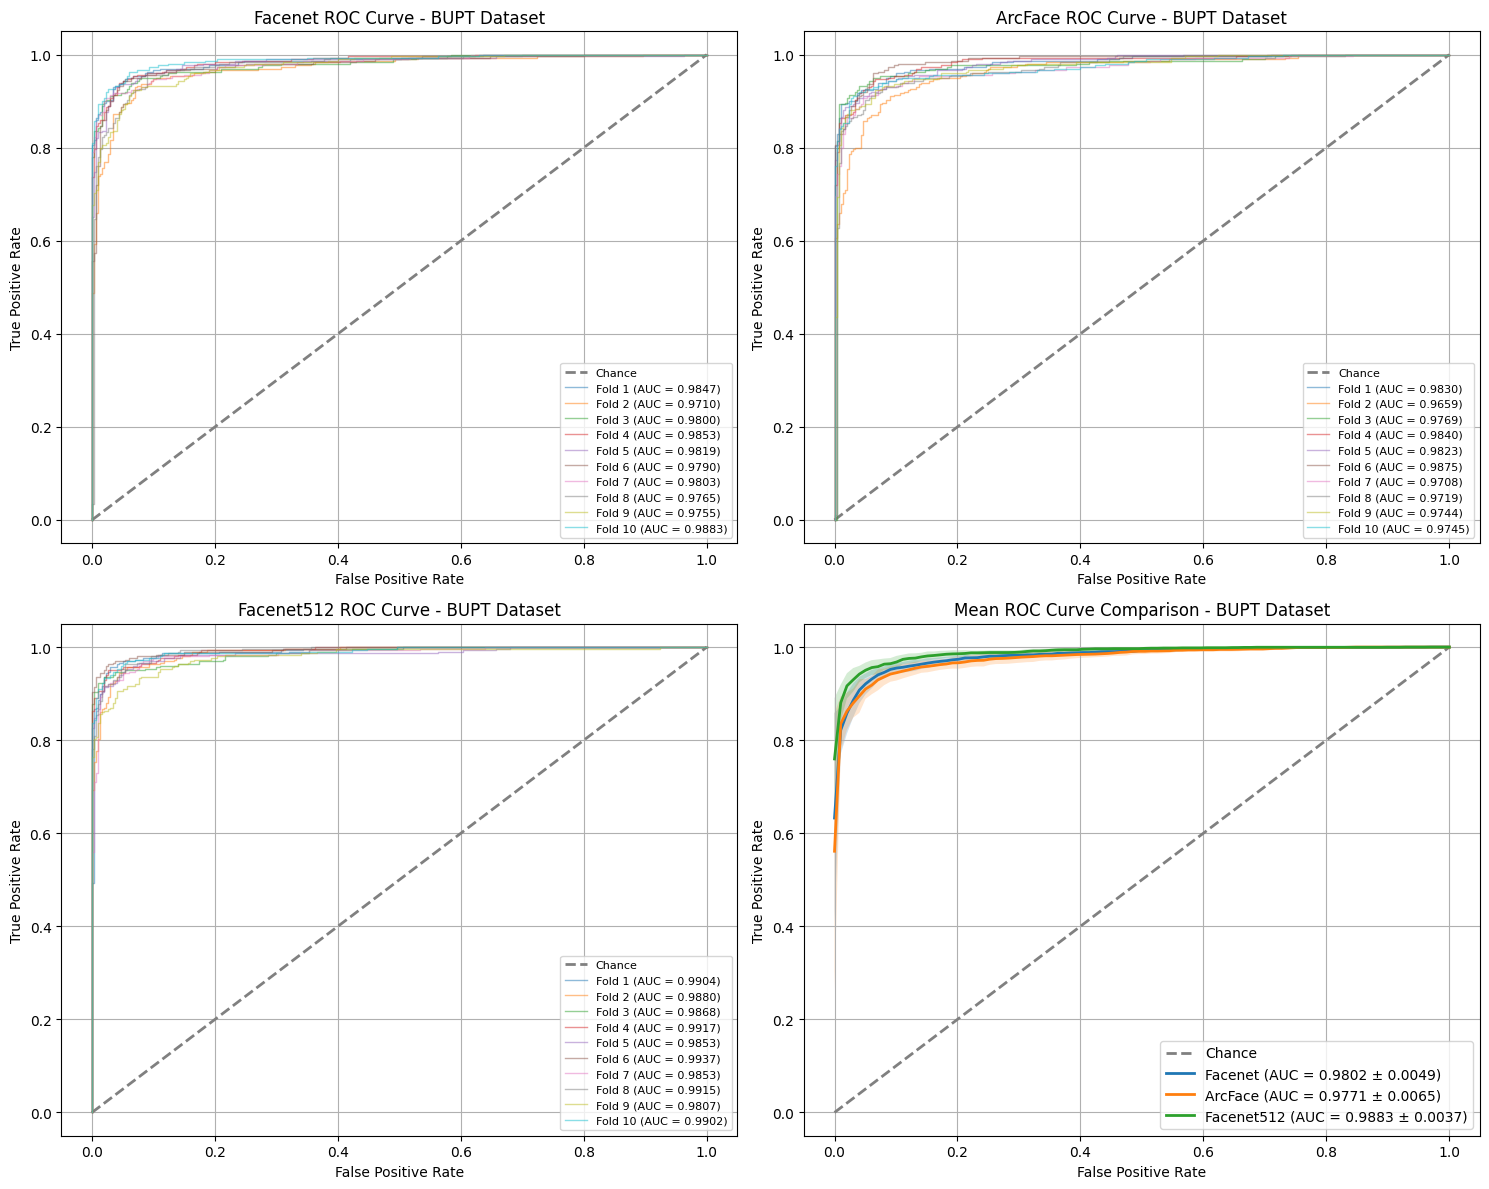

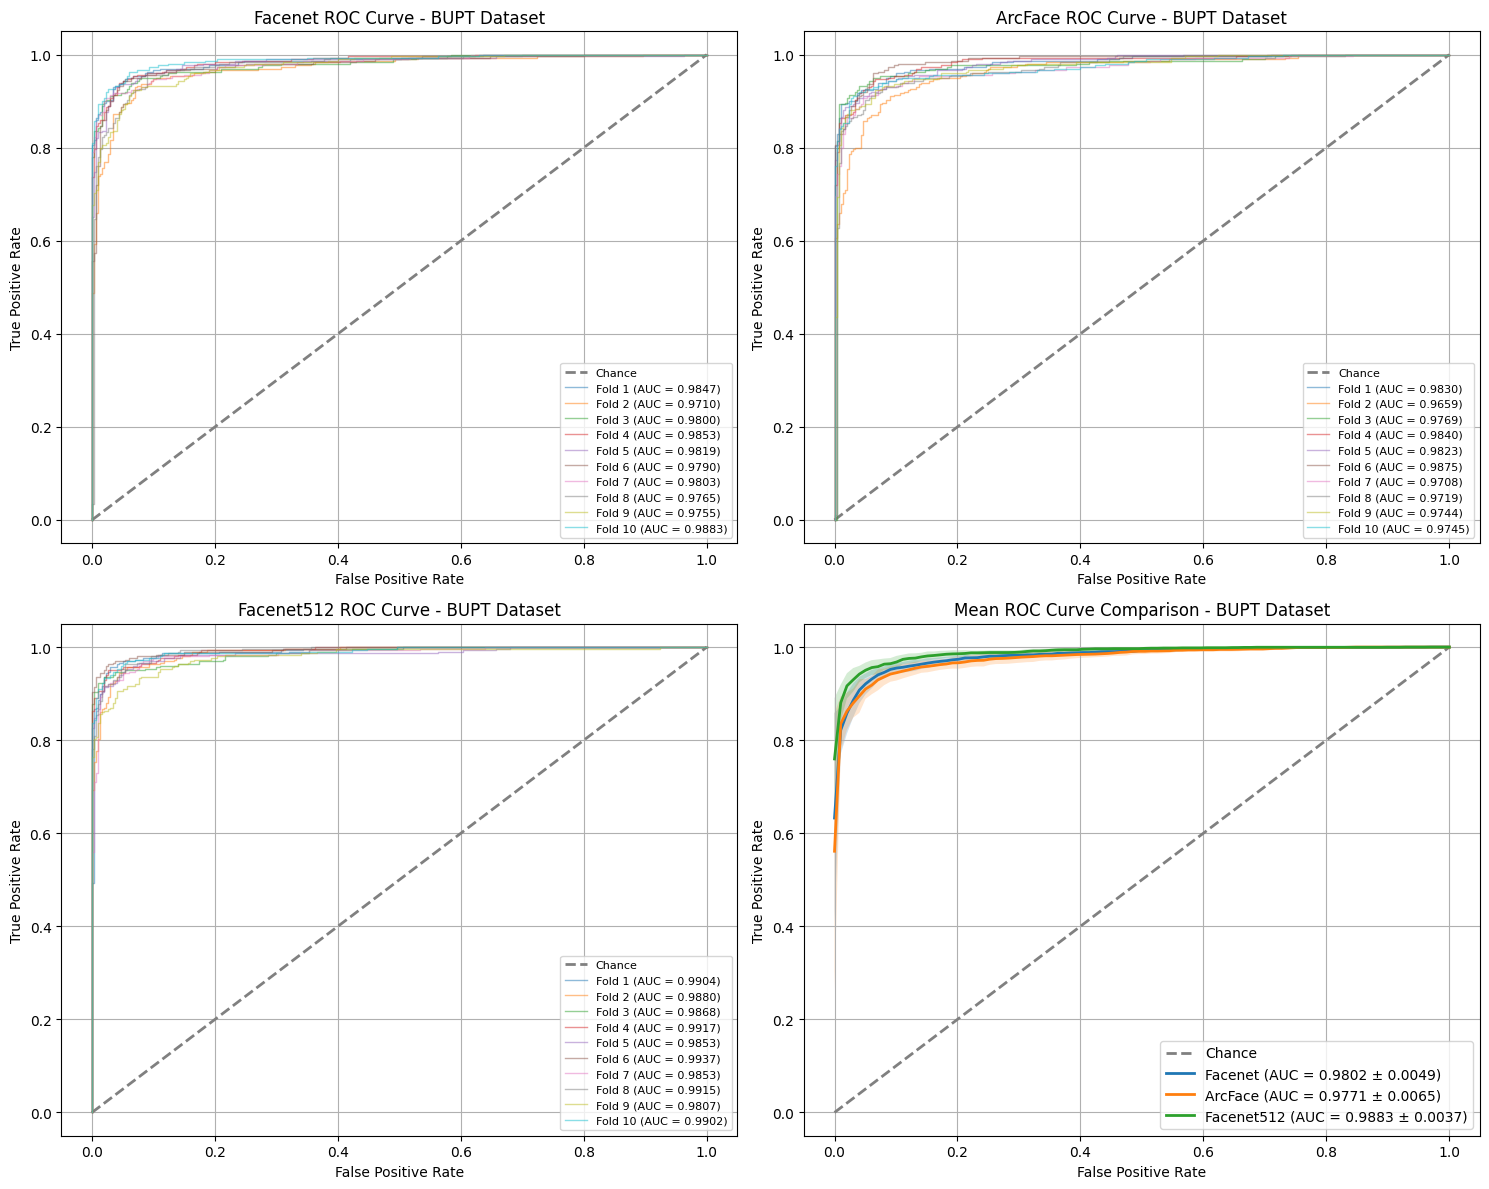

In [20]:
# ROC Curves
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Plot individual model ROC curves
for i, model_name in enumerate(models):
    ax = axes[i]
    ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray', label='Chance')
    all_fpr, all_tpr, aucs = [], [], all_cv_results[model_name]['aucs']
    for fold in range(n_splits):
        distances = all_cv_results[model_name]['distances'][fold]
        fold_labels = all_cv_results[model_name]['fold_labels'][fold]
        fpr, tpr, _ = roc_curve(fold_labels, -np.array(distances))
        all_fpr.append(fpr)
        all_tpr.append(tpr)
        ax.plot(fpr, tpr, lw=1, alpha=0.5, label=f'Fold {fold + 1} (AUC = {aucs[fold]:.4f})')

    ax.set_title(f"{model_name} ROC Curve - BUPT Dataset")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True)
    ax.legend(loc="lower right", fontsize=8)

# Plot mean ROC curves for all models
ax_mean = axes[3]
ax_mean.plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray', label='Chance')
for model_name in models:
    all_fpr, all_tpr, aucs = [], [], all_cv_results[model_name]['aucs']
    for fold in range(n_splits):
        distances = all_cv_results[model_name]['distances'][fold]
        fold_labels = all_cv_results[model_name]['fold_labels'][fold]
        fpr, tpr, _ = roc_curve(fold_labels, -np.array(distances))
        all_fpr.append(fpr)
        all_tpr.append(tpr)

    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.mean([np.interp(mean_fpr, all_fpr[i], all_tpr[i]) for i in range(n_splits)], axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = np.std([np.interp(mean_fpr, all_fpr[i], all_tpr[i]) for i in range(n_splits)], axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    ax_mean.plot(mean_fpr, mean_tpr, label=f'{model_name} (AUC = {mean_auc:.4f} ± {std_auc:.4f})', lw=2)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    ax_mean.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.2)

ax_mean.set_title("Mean ROC Curve Comparison - BUPT Dataset")
ax_mean.set_xlabel("False Positive Rate")
ax_mean.set_ylabel("True Positive Rate")
ax_mean.grid(True)
ax_mean.legend(loc="lower right")

plt.tight_layout()
plt.savefig("bupt_roc_curves.png", dpi=300)
plt.show()

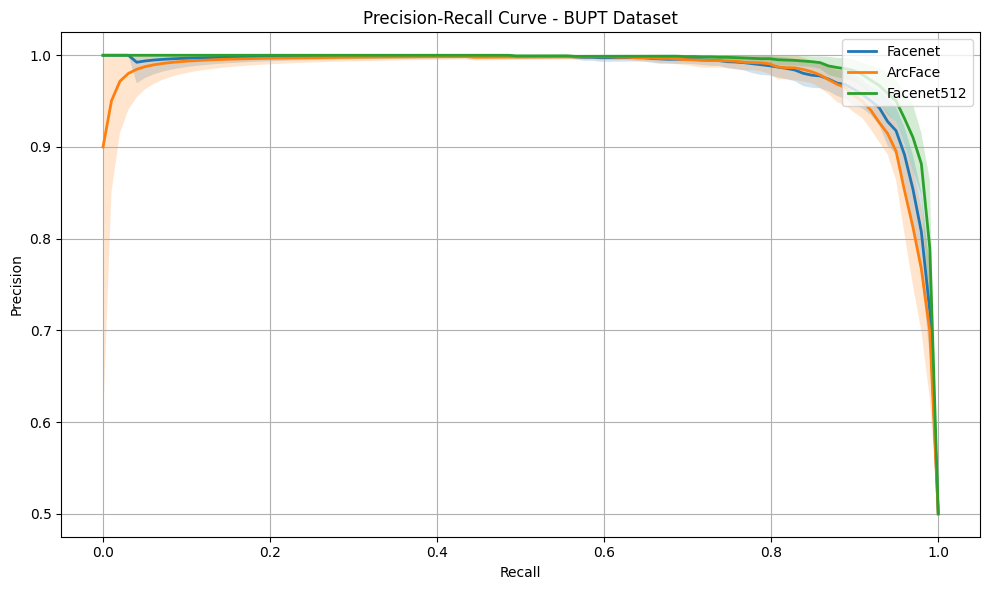

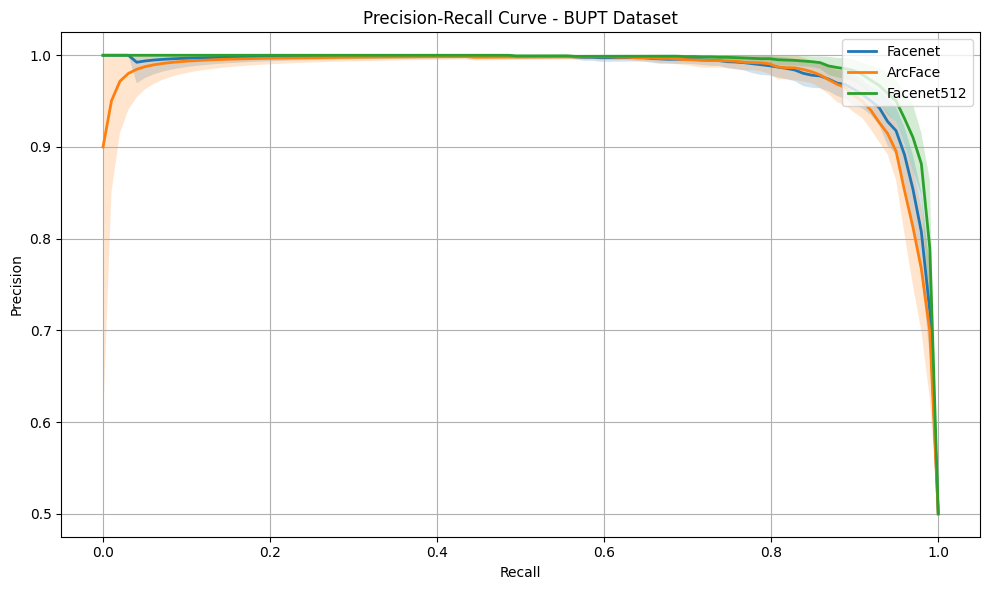

In [21]:
# Precision-Recall Curve
plt.figure(figsize=(10, 6))
for model_name in models:
    all_precision, all_recall = [], []
    for fold in range(n_splits):
        distances = all_cv_results[model_name]['distances'][fold]
        fold_labels = all_cv_results[model_name]['fold_labels'][fold]
        precision, recall, _ = precision_recall_curve(fold_labels, -np.array(distances))
        all_precision.append(precision)
        all_recall.append(recall)

    mean_recall = np.linspace(0, 1, 100)
    mean_precision = np.mean([np.interp(mean_recall, all_recall[i][::-1], all_precision[i][::-1])
                              for i in range(n_splits)], axis=0)
    std_precision = np.std([np.interp(mean_recall, all_recall[i][::-1], all_precision[i][::-1])
                            for i in range(n_splits)], axis=0)
    plt.plot(mean_recall, mean_precision, label=f'{model_name}', lw=2)
    plt.fill_between(mean_recall,
                     np.maximum(mean_precision - std_precision, 0),
                     np.minimum(mean_precision + std_precision, 1),
                     alpha=0.2)

plt.title("Precision-Recall Curve - BUPT Dataset")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("bupt_precision_recall.png", dpi=300)
plt.show()

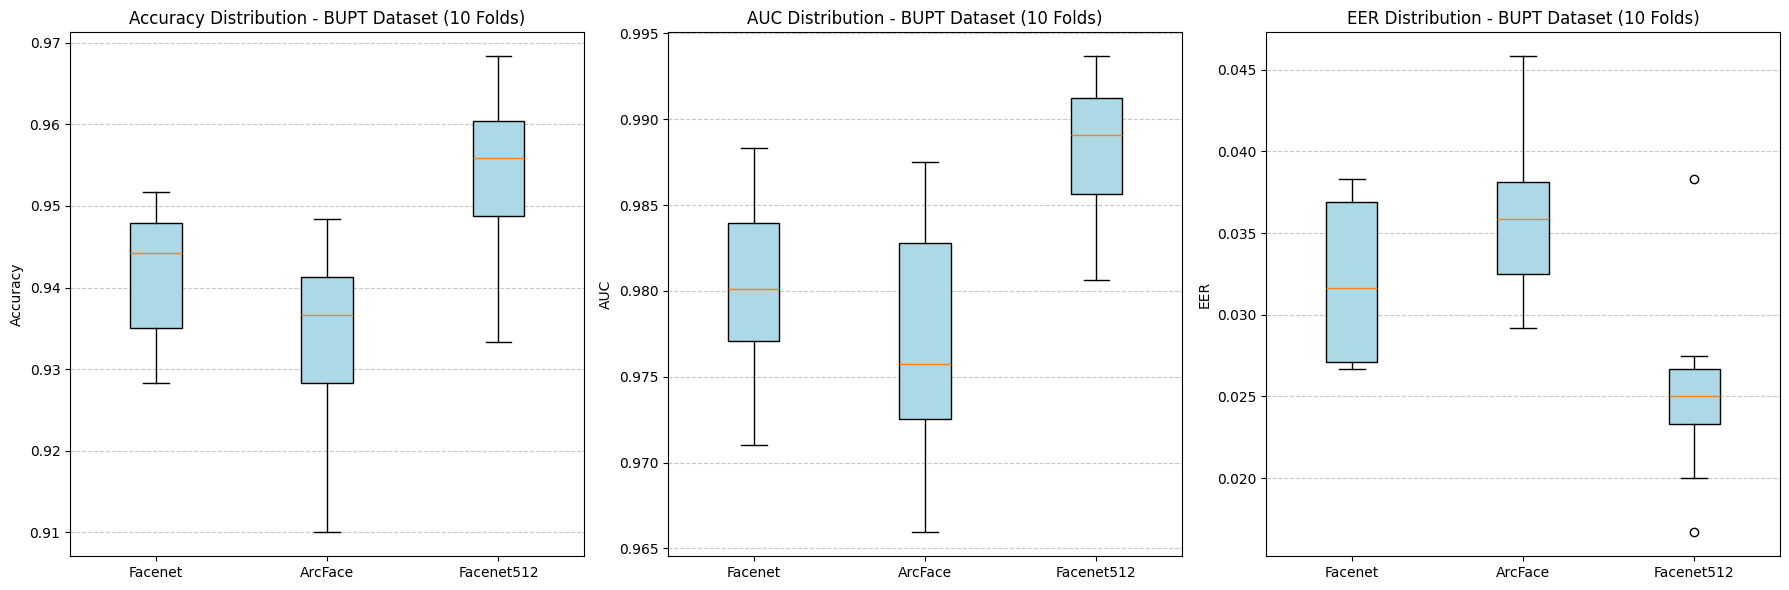

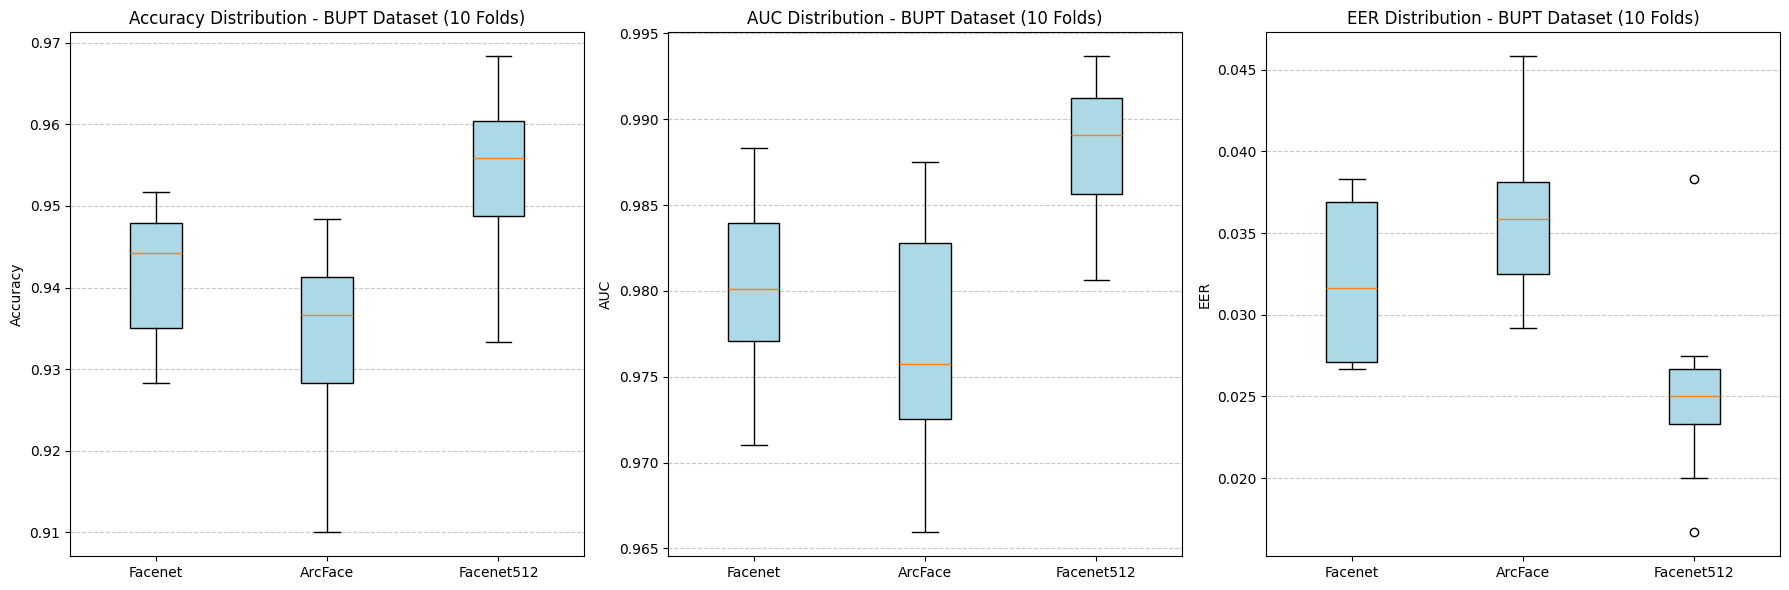

In [22]:
# Box plots for metrics
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
metrics_to_plot = {'Accuracy': 'accuracies', 'AUC': 'aucs', 'EER': 'eers'}
for i, (metric_name, data_key) in enumerate(metrics_to_plot.items()):
    metric_data = [all_cv_results[model][data_key] for model in models]
    axes[i].boxplot(metric_data, labels=models, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'{metric_name} Distribution - BUPT Dataset ({n_splits} Folds)')
    axes[i].set_ylabel(metric_name)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("bupt_metric_boxplots.png", dpi=300)
plt.show()

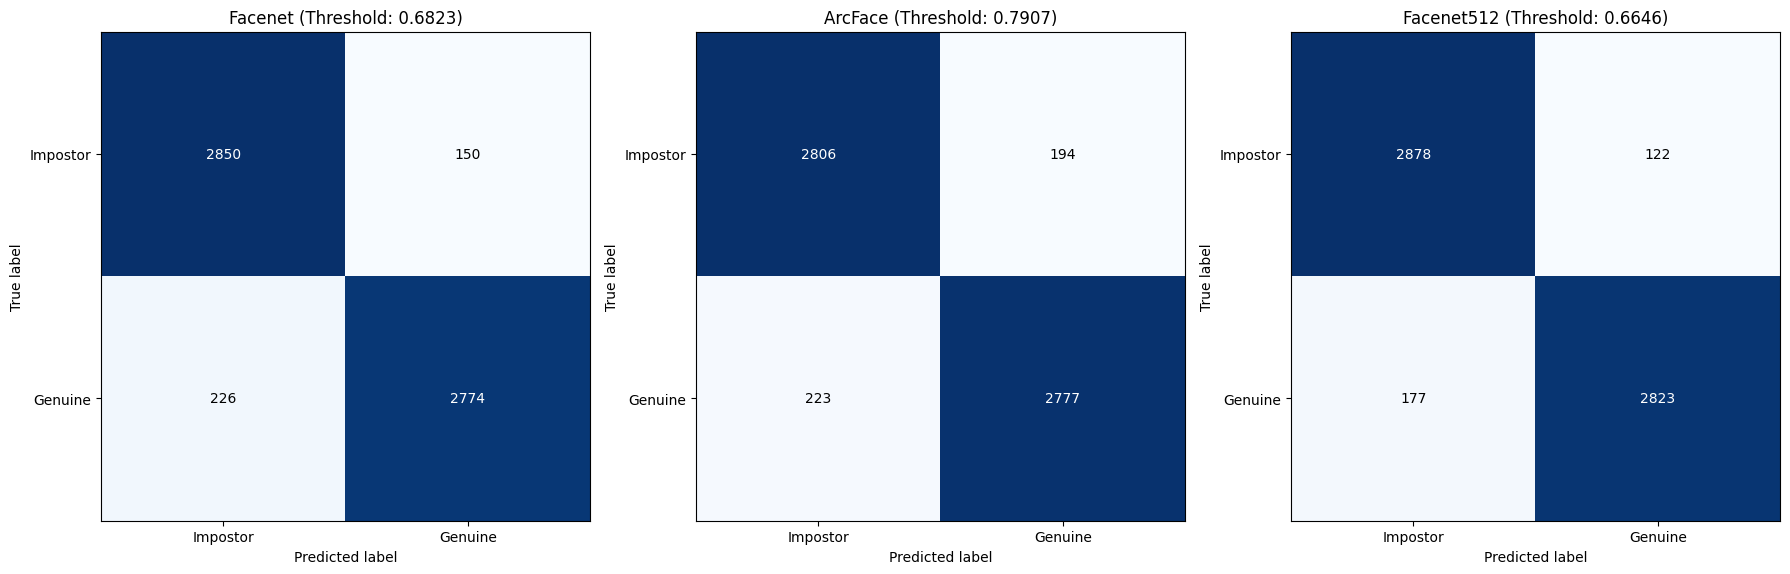

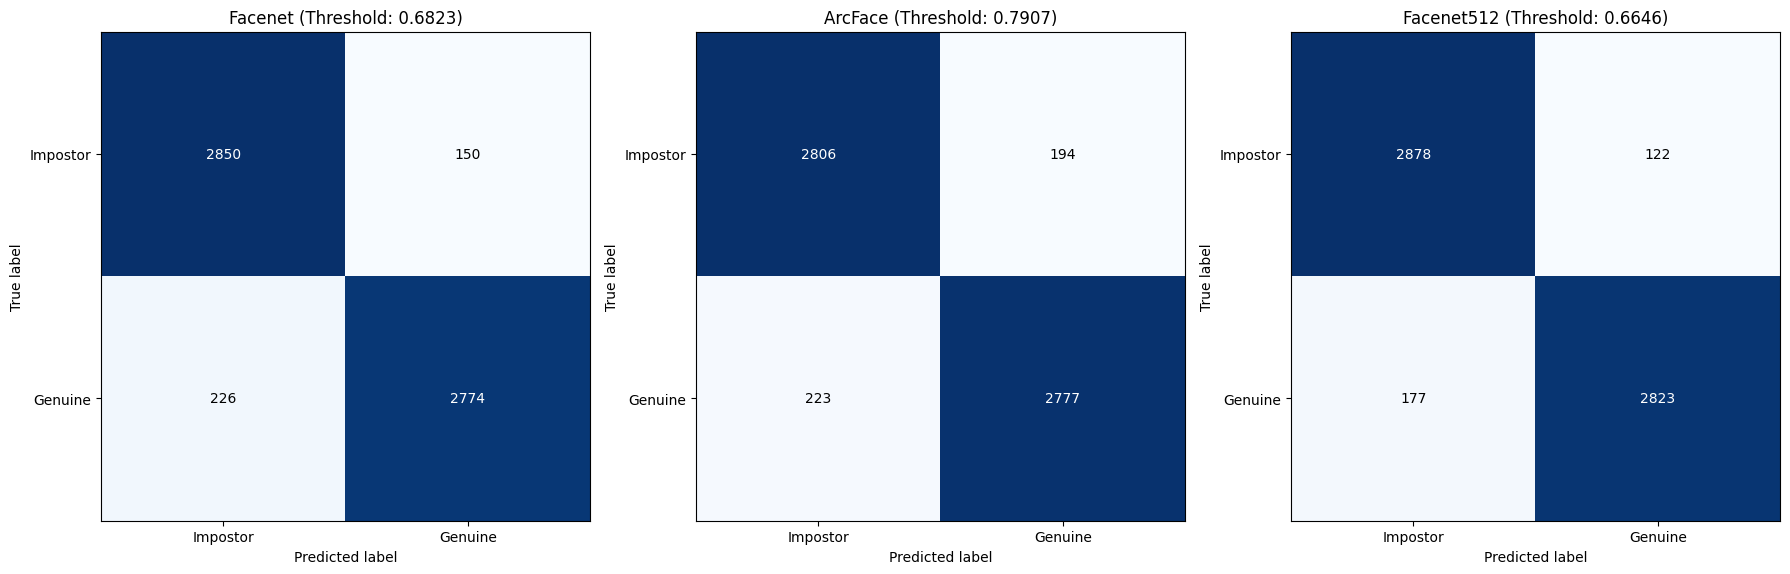

In [23]:
# Confusion Matrices
fig, axes = plt.subplots(nrows=1, ncols=len(models), figsize=(18, 6))
if len(models) == 1:
    axes = [axes]

for i, model_name in enumerate(models):
    combined_distances = np.concatenate(all_cv_results[model_name]['distances'])
    combined_labels = np.array(y_trues_all_folds)
    optimal_thresh = find_optimal_threshold(combined_distances, combined_labels)
    preds = combined_distances < optimal_thresh
    cm = confusion_matrix(combined_labels, preds)

    ax = axes[i]
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'{model_name} (Threshold: {optimal_thresh:.4f})')

    # Add text annotations
    for k in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, k, format(cm[k, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[k, j] > cm.max() / 2 else "black")

    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(['Impostor', 'Genuine'])
    ax.set_yticklabels(['Impostor', 'Genuine'])
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.tight_layout()
plt.savefig("bupt_confusion_matrices.png", dpi=300)
plt.show()

In [24]:
# Save results
results_json = {
    'dataset': 'BUPT-CBFace-12 (6000 pairs subset)',
    'total_pairs': len(labels),
    'genuine_pairs': int(sum(labels)),
    'impostor_pairs': int(len(labels) - sum(labels)),
    'models': results_data,
    'note': 'BUPT-CBFace provides a more challenging evaluation than LFW with higher diversity in poses, expressions, and image conditions'
}

with open('bupt_evaluation_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)

print("\nResults saved to bupt_evaluation_results.json")


Results saved to bupt_evaluation_results.json

Results saved to bupt_evaluation_results.json


In [25]:
print("\n" + "=" * 70)
print("EVALUATION COMPLETE")
print("=" * 70)
print("""
Key Points:
1. BUPT-CBFace is more challenging than LFW
2. Dataset has 41,667 identities (vs LFW's 5,749)
3. Higher diversity in poses, expressions, and conditions
4. Results demonstrate model robustness on harder data

For the paper, you can report:
- Performance comparison between LFW and BUPT-CBFace
- Shows generalization to more challenging conditions
- Validates approach on multiple datasets
""")


EVALUATION COMPLETE

Key Points:
1. BUPT-CBFace is more challenging than LFW
2. Dataset has 41,667 identities (vs LFW's 5,749)
3. Higher diversity in poses, expressions, and conditions
4. Results demonstrate model robustness on harder data

For the paper, you can report:
- Performance comparison between LFW and BUPT-CBFace
- Shows generalization to more challenging conditions
- Validates approach on multiple datasets


EVALUATION COMPLETE

Key Points:
1. BUPT-CBFace is more challenging than LFW
2. Dataset has 41,667 identities (vs LFW's 5,749)
3. Higher diversity in poses, expressions, and conditions
4. Results demonstrate model robustness on harder data

For the paper, you can report:
- Performance comparison between LFW and BUPT-CBFace
- Shows generalization to more challenging conditions
- Validates approach on multiple datasets



In [18]:
# Clean up
import os
import shutil

if os.path.exists("bupt_subset"):
    print("\nCleaning up extracted files...")
    shutil.rmtree("bupt_subset")
    print("Cleanup complete.")


Cleaning up extracted files...
Cleanup complete.
